### Comparision

Model Name                | AUC    | AUPRC  | Brier  | ECE   
-----------------------------------------------------------------
Logistic (Baseline)       | 0.8018 | 0.6542 | 0.1575 | 0.0633
Logistic with no GICS     | 0.7920 | 0.6533 | 0.1589 | 0.0681
Random Forest             | 0.8133 | 0.6662 | 0.1503 | 0.0571
XGBoost                   | 0.8222 | 0.6864 | 0.1499 | 0.0638
SVM                       | 0.7751 | 0.5780 | 0.1701 | 0.0583
Neural Network            | 0.8154 | 0.6674 | 0.1553 | 0.0634
Gradient Boosting               | 0.8173 | 0.6840 | 0.1490 | 0.0715


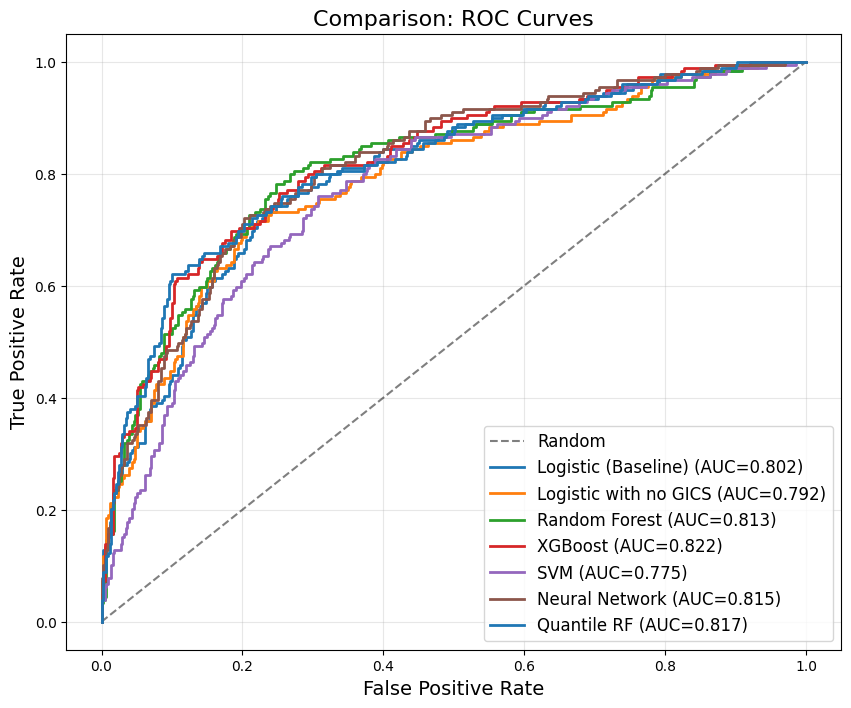

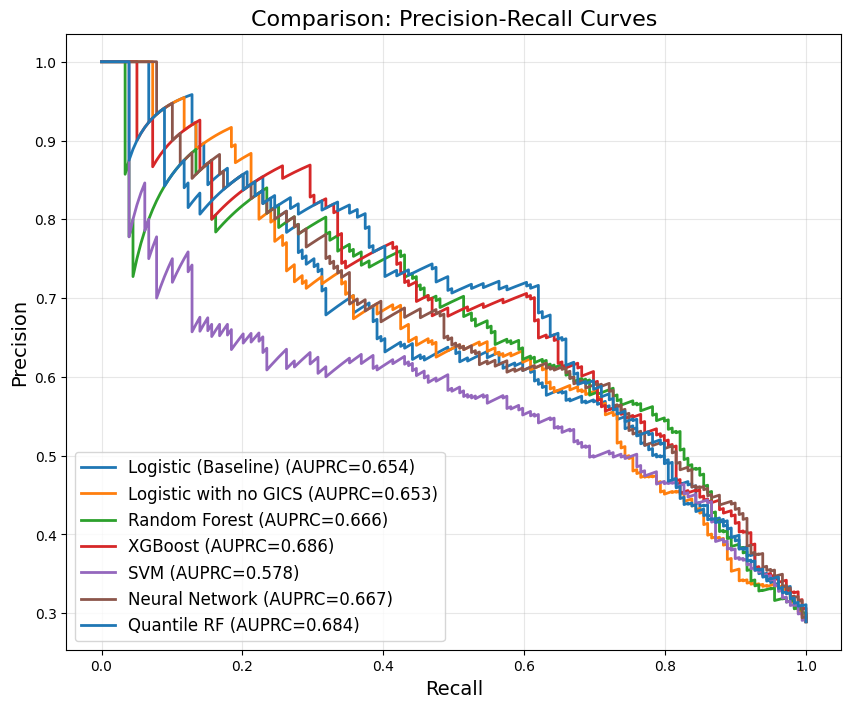

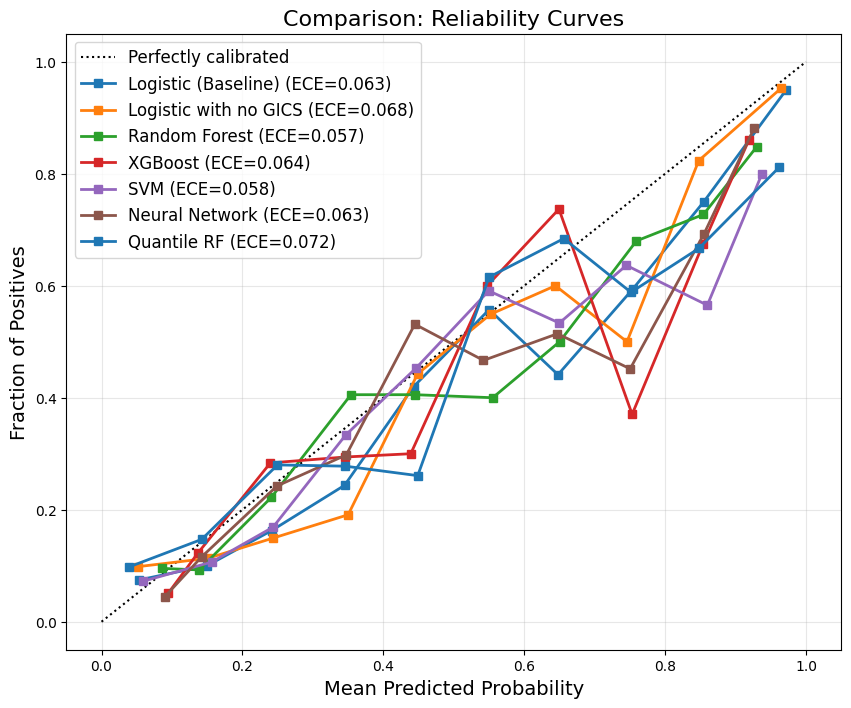

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve


model_dict = {
    "Logistic (Baseline)": "ML and FT/project/outputs/logistic_baseline/predictions_test.csv",
    "Logistic with no GICS":"ML and FT/project/outputs/logistic_baseline_no_gics/logistic_nogics_predictions_test.csv",
    "Random Forest":       "ML and FT/project/outputs/rf_model/rf_predictions_test.csv",
    "XGBoost":             "ML and FT/project/outputs/xgboost_model/xgboost_predictions_test.csv",
    "SVM":                 "ML and FT/project/outputs/svm_model/svm_predictions_test.csv",
    "Neural Network":      "ML and FT/project/outputs/nn_model/nn_predictions_test.csv",
    "Gradient Boosting":         "ML and FT/project/outputs/gb_model/gb_predictions_test.csv"
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
results = []

# --- 定義 ECE 計算函數 ---
def get_ece(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i+1]
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop = in_bin.mean()
        if prop > 0:
            acc = y_true[in_bin].mean()
            conf = y_prob[in_bin].mean()
            ece += np.abs(conf - acc) * prop
    return ece



print(f"{'Model Name':<25} | {'AUC':<6} | {'AUPRC':<6} | {'Brier':<6} | {'ECE':<6}") 
print("-" * 65)

for i, (name, filename) in enumerate(model_dict.items()):
    file_path = None
    possible_paths = [filename, f"outputs/{filename}", f"project/outputs/{filename}"]
    
    for p in possible_paths:
        if os.path.exists(p):
            file_path = p
            break
            
    if file_path is None:
        print(f"找不到 {name} 的檔案 ({filename})。")
        continue

    # 讀取資料
    df = pd.read_csv(file_path)
    y_true = df['y_true']
    y_prob = df['p_platt'] if 'p_platt' in df.columns else df['p_raw']

    # --- 計算指標 ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    
    frac, mean = calibration_curve(y_true, y_prob, n_bins=10)
    brier = brier_score_loss(y_true, y_prob)
    
    # 計算 ECE
    ece = get_ece(y_true, y_prob)

    # 印出數據 (包含 ECE)
    print(f"{name:<25} | {roc_auc:.4f} | {auprc:.4f} | {brier:.4f} | {ece:.4f}")
    
    results.append({
        'name': name,
        'color': colors[i % len(colors)],
        'fpr': fpr, 'tpr': tpr, 'roc_auc': roc_auc,
        'precision': precision, 'recall': recall, 'auprc': auprc,
        'frac': frac, 'mean': mean, 'brier': brier, 'ece': ece
    })



# --- 第一張：ROC Curve ---
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
for res in results:
    plt.plot(res['fpr'], res['tpr'], lw=2, color=res['color'], 
             label=f"{res['name']} (AUC={res['roc_auc']:.3f})")
plt.title('Comparison: ROC Curves', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# --- 第二張：Precision-Recall Curve ---
plt.figure(figsize=(10, 8))
for res in results:
    plt.plot(res['recall'], res['precision'], lw=2, color=res['color'], 
             label=f"{res['name']} (AUPRC={res['auprc']:.3f})")
plt.title('Comparison: Precision-Recall Curves', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.legend(loc="lower left", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# --- 第三張：Calibration Curve ---
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k:', label="Perfectly calibrated")
for res in results:
    plt.plot(res['mean'], res['frac'], "s-", lw=2, color=res['color'], 
             label=f"{res['name']} (ECE={res['ece']:.3f})")
plt.title('Comparison: Reliability Curves', fontsize=16)
plt.xlabel('Mean Predicted Probability', fontsize=14)
plt.ylabel('Fraction of Positives', fontsize=14)
plt.legend(loc="best", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### logistic regression (baseline model)

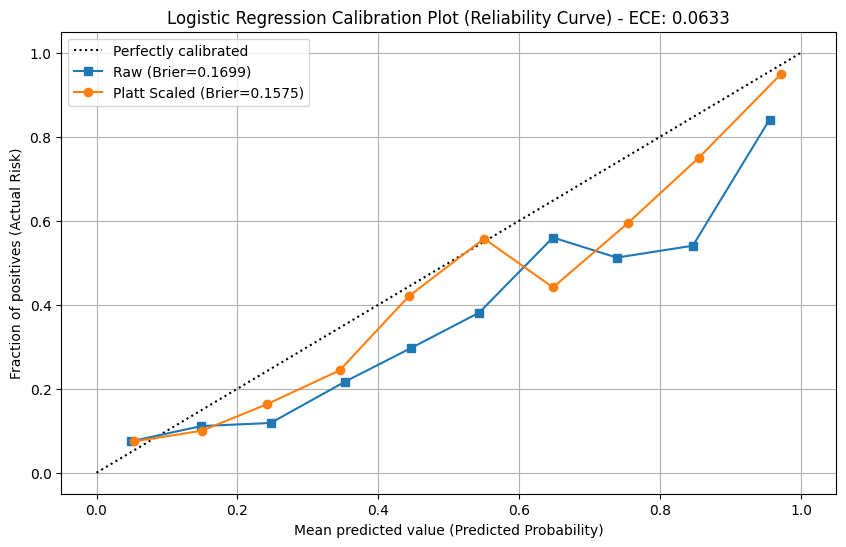

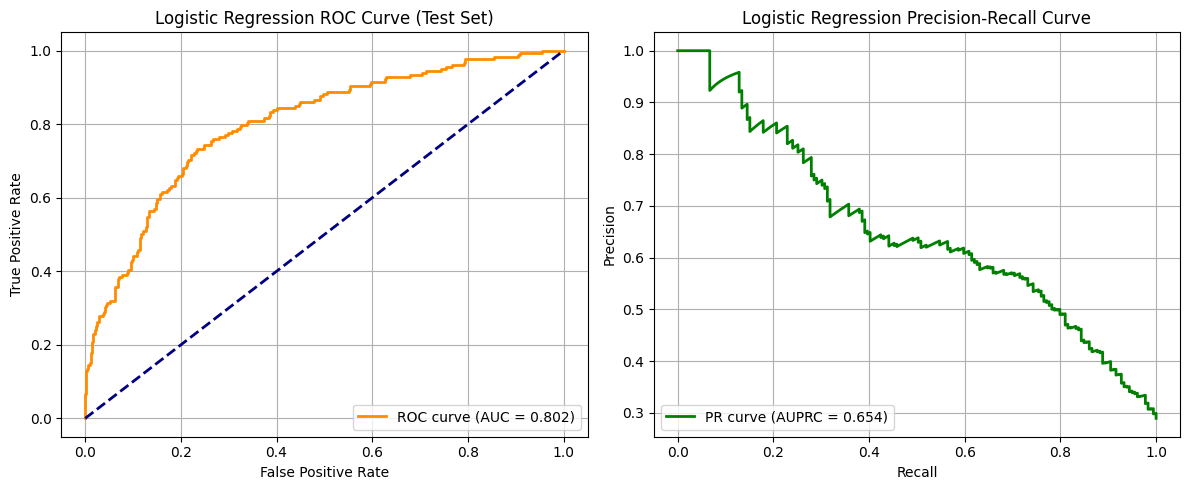

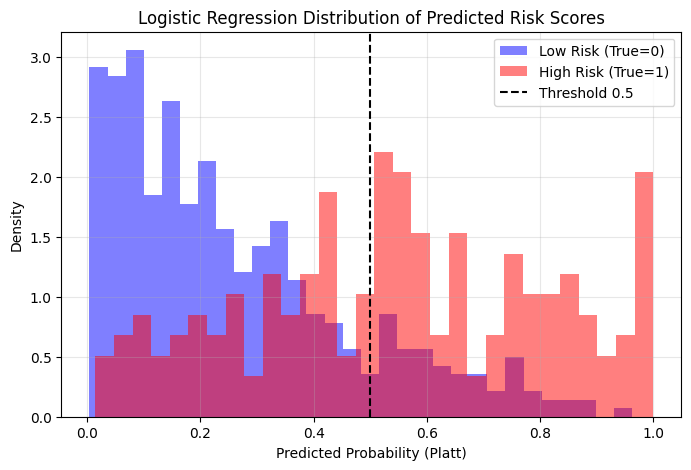

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_curve, auc, precision_recall_curve, average_precision_score

# ==========================================
# 1. 讀取預測結果
# ==========================================
# 請確認檔案路徑是否正確，通常在 outputs/logistic_baseline/ 下
file_path = "ML and FT/project/outputs/logistic_baseline/predictions_test.csv"
try:
    preds = pd.read_csv(file_path)
    #print(f"成功讀取檔案: {file_path}, 共 {len(preds)} 筆資料")
except FileNotFoundError:
    print(f"找不到檔案: {file_path}，請確認路徑。")
    # 如果找不到，這裡用假資料避免程式報錯 (僅供測試)
    # preds = pd.DataFrame({'y_true': [0,1,0,1], 'p_raw': [0.1,0.9,0.2,0.8], 'p_platt': [0.15,0.85,0.25,0.75]})

y_true = preds['y_true']
prob_raw = preds['p_raw']
prob_platt = preds['p_platt']

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # 落入該區間的樣本
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()  # 該區間樣本佔比
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()  # 實際違約率
            avg_confidence_in_bin = y_prob[in_bin].mean()  # 平均預測機率
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
    return ece

ece_score = expected_calibration_error(y_true, prob_platt)
#print(f"ECE Score: {ece_score:.4f}")

# ==========================================
# 2. 畫圖：校準度分析 (Reliability Curve)
# ==========================================
plt.figure(figsize=(10, 6))

# 計算 Brier Score
brier_raw = brier_score_loss(y_true, prob_raw)
brier_platt = brier_score_loss(y_true, prob_platt)

# 畫對角線 (完美校準)
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

# 畫 Raw 模型
frac_raw, mean_raw = calibration_curve(y_true, prob_raw, n_bins=10)
plt.plot(mean_raw, frac_raw, "s-", label=f"Raw (Brier={brier_raw:.4f})")

# 畫 Platt 校準後模型
frac_platt, mean_platt = calibration_curve(y_true, prob_platt, n_bins=10)
#plt.plot(mean_platt, frac_platt, "o-", label=f"Platt Scaled (Brier={brier_platt:.4f})")


plt.plot(mean_platt, frac_platt, "o-", label=f"Platt Scaled (Brier={brier_platt:.4f})")
# 修改標題，加上 ECE
plt.title(f"Logistic Regression Calibration Plot (Reliability Curve) - ECE: {ece_score:.4f}")

plt.ylabel("Fraction of positives (Actual Risk)")
plt.xlabel("Mean predicted value (Predicted Probability)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# ==========================================
# 3. 畫圖：效能指標 (ROC & PR Curve)
# ==========================================
plt.figure(figsize=(12, 5))

# --- 左圖：ROC Curve ---
plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_true, prob_platt)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve (Test Set)')
plt.legend(loc="lower right")
plt.grid(True)

# --- 右圖：Precision-Recall Curve ---
plt.subplot(1, 2, 2)
precision, recall, _ = precision_recall_curve(y_true, prob_platt)
auprc = average_precision_score(y_true, prob_platt)
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUPRC = {auprc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Logistic Regression Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. 畫圖：機率分佈圖 (Risk Distribution)
# ==========================================
plt.figure(figsize=(8, 5))
plt.hist(prob_platt[y_true == 0], bins=30, alpha=0.5, label='Low Risk (True=0)', density=True, color='blue')
plt.hist(prob_platt[y_true == 1], bins=30, alpha=0.5, label='High Risk (True=1)', density=True, color='red')
plt.axvline(0.5, color='k', linestyle='--', label='Threshold 0.5')
plt.xlabel('Predicted Probability (Platt)')
plt.ylabel('Density')
plt.title('Logistic Regression Distribution of Predicted Risk Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### calibration plot
藍線 (Raw)：在低機率區（0.0 - 0.4）它在虛線下方，代表模型低估了風險（Under-confident）；在高機率區則波動較大。Brier Score 為 0.1699。
橘線 (Platt Scaled)：經過校準後的預測。這條線明顯比藍線更貼近對角虛線，特別是在 0.0 - 0.6 的區間。Brier Score 降至 0.1575（越低越好）。
### precision recall
曲線平滑下降，沒有斷崖式下跌，表示模型穩定。
當 Recall (召回率) 達到 0.6 時，Precision (準確率) 仍能維持在 0.6 左右。這意味著如果我們想抓出 60% 的違約者，我們抓出來的名單中，有 60% 是真的會違約的。

### XGBoost

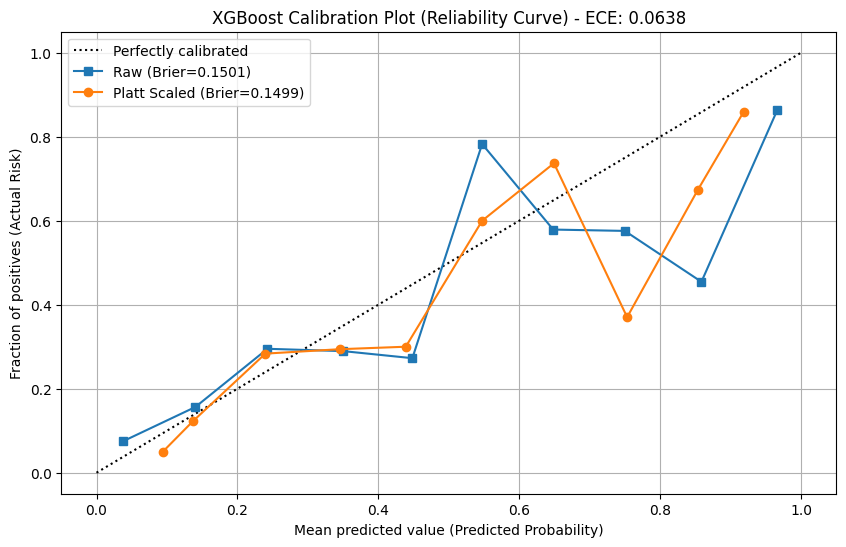

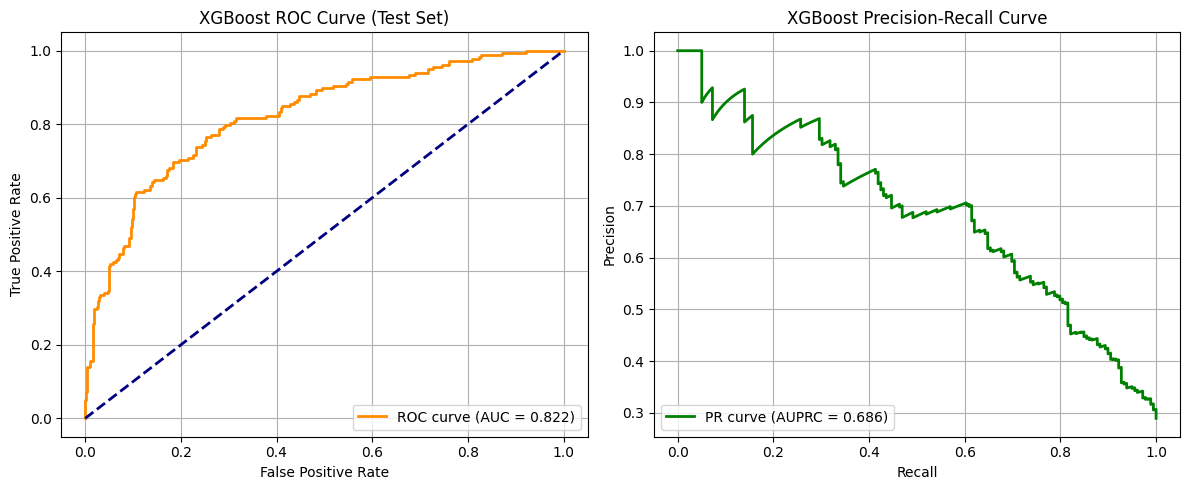

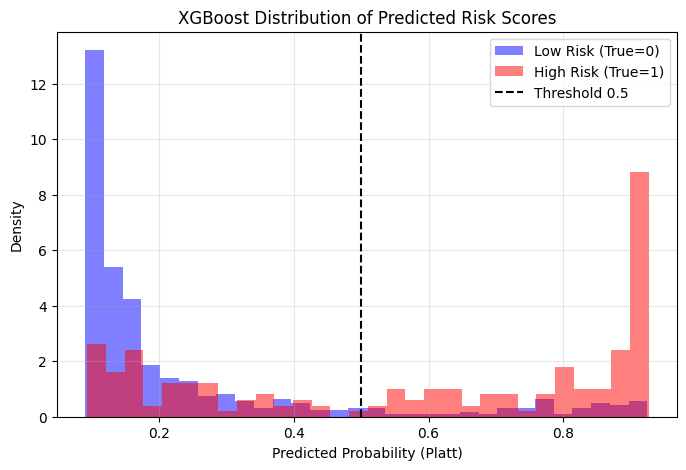

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_curve, auc, precision_recall_curve, average_precision_score

# ==========================================
# 1. 讀取預測結果
# ==========================================
# 請確認檔案路徑是否正確，通常在 outputs/logistic_baseline/ 下
file_path = "ML and FT/project/outputs/xgboost_model/xgboost_predictions_test.csv"
try:
    preds = pd.read_csv(file_path)
    #print(f"成功讀取檔案: {file_path}, 共 {len(preds)} 筆資料")
except FileNotFoundError:
    print(f"找不到檔案: {file_path}，請確認路徑。")
    # 如果找不到，這裡用假資料避免程式報錯 (僅供測試)
    # preds = pd.DataFrame({'y_true': [0,1,0,1], 'p_raw': [0.1,0.9,0.2,0.8], 'p_platt': [0.15,0.85,0.25,0.75]})

y_true = preds['y_true']
prob_raw = preds['p_raw']
prob_platt = preds['p_platt']

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # 落入該區間的樣本
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()  # 該區間樣本佔比
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()  # 實際違約率
            avg_confidence_in_bin = y_prob[in_bin].mean()  # 平均預測機率
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
    return ece

ece_score = expected_calibration_error(y_true, prob_platt)
#print(f"ECE Score: {ece_score:.4f}")

# ==========================================
# 2. 畫圖：校準度分析 (Reliability Curve)
# ==========================================
plt.figure(figsize=(10, 6))

# 計算 Brier Score
brier_raw = brier_score_loss(y_true, prob_raw)
brier_platt = brier_score_loss(y_true, prob_platt)

# 畫對角線 (完美校準)
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

# 畫 Raw 模型
frac_raw, mean_raw = calibration_curve(y_true, prob_raw, n_bins=10)
plt.plot(mean_raw, frac_raw, "s-", label=f"Raw (Brier={brier_raw:.4f})")

# 畫 Platt 校準後模型
frac_platt, mean_platt = calibration_curve(y_true, prob_platt, n_bins=10)
#plt.plot(mean_platt, frac_platt, "o-", label=f"Platt Scaled (Brier={brier_platt:.4f})")


plt.plot(mean_platt, frac_platt, "o-", label=f"Platt Scaled (Brier={brier_platt:.4f})")
# 修改標題，加上 ECE
plt.title(f"XGBoost Calibration Plot (Reliability Curve) - ECE: {ece_score:.4f}")

plt.ylabel("Fraction of positives (Actual Risk)")
plt.xlabel("Mean predicted value (Predicted Probability)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# ==========================================
# 3. 畫圖：效能指標 (ROC & PR Curve)
# ==========================================
plt.figure(figsize=(12, 5))

# --- 左圖：ROC Curve ---
plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_true, prob_platt)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve (Test Set)')
plt.legend(loc="lower right")
plt.grid(True)

# --- 右圖：Precision-Recall Curve ---
plt.subplot(1, 2, 2)
precision, recall, _ = precision_recall_curve(y_true, prob_platt)
auprc = average_precision_score(y_true, prob_platt)
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUPRC = {auprc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. 畫圖：機率分佈圖 (Risk Distribution)
# ==========================================
plt.figure(figsize=(8, 5))
plt.hist(prob_platt[y_true == 0], bins=30, alpha=0.5, label='Low Risk (True=0)', density=True, color='blue')
plt.hist(prob_platt[y_true == 1], bins=30, alpha=0.5, label='High Risk (True=1)', density=True, color='red')
plt.axvline(0.5, color='k', linestyle='--', label='Threshold 0.5')
plt.xlabel('Predicted Probability (Platt)')
plt.ylabel('Density')
plt.title('XGBoost Distribution of Predicted Risk Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### logistic regression (no GICS)

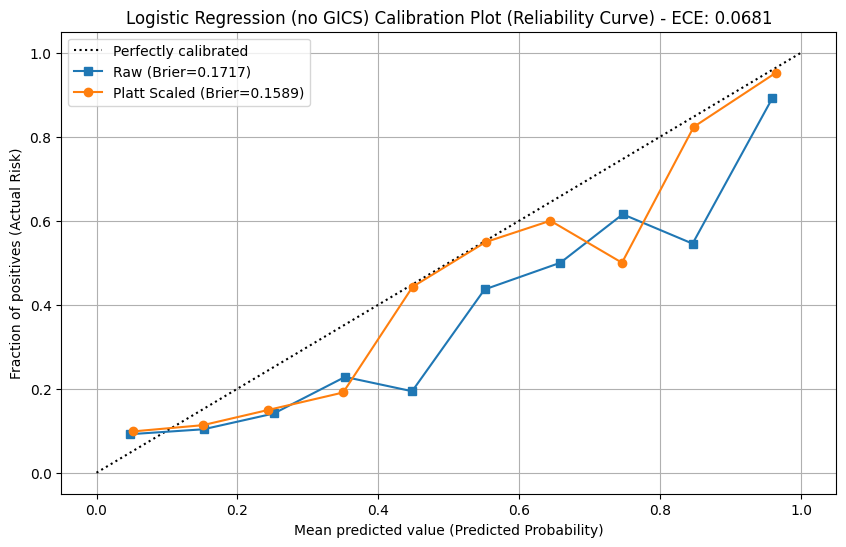

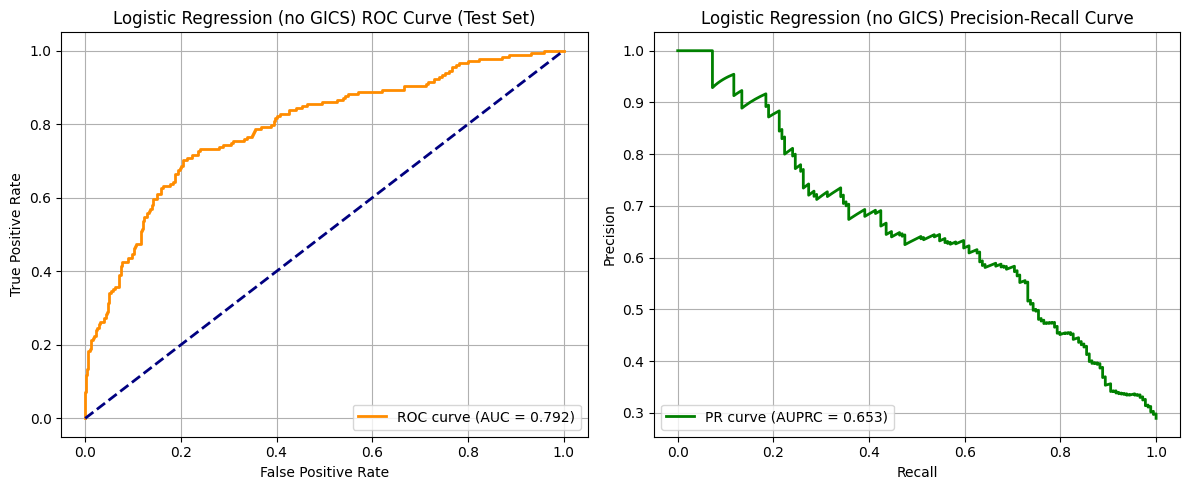

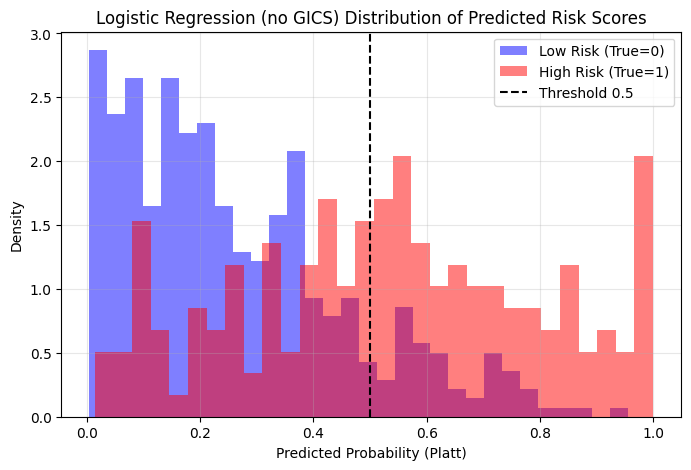

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_curve, auc, precision_recall_curve, average_precision_score

file_path = "ML and FT/project/outputs/logistic_baseline_no_gics/logistic_nogics_predictions_test.csv"
try:
    preds = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"找不到檔案: {file_path}，請確認路徑。")

y_true = preds['y_true']
prob_raw = preds['p_raw']
prob_platt = preds['p_platt']

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # 落入該區間的樣本
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()  # 該區間樣本佔比
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()  # 實際違約率
            avg_confidence_in_bin = y_prob[in_bin].mean()  # 平均預測機率
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
    return ece

ece_score = expected_calibration_error(y_true, prob_platt)
#print(f"ECE Score: {ece_score:.4f}")

# ==========================================
# 畫圖：校準度分析 (Reliability Curve)
# ==========================================
plt.figure(figsize=(10, 6))

# 計算 Brier Score
brier_raw = brier_score_loss(y_true, prob_raw)
brier_platt = brier_score_loss(y_true, prob_platt)

# 畫對角線 (完美校準)
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

# 畫 Raw 模型
frac_raw, mean_raw = calibration_curve(y_true, prob_raw, n_bins=10)
plt.plot(mean_raw, frac_raw, "s-", label=f"Raw (Brier={brier_raw:.4f})")

# 畫 Platt 校準後模型
frac_platt, mean_platt = calibration_curve(y_true, prob_platt, n_bins=10)
#plt.plot(mean_platt, frac_platt, "o-", label=f"Platt Scaled (Brier={brier_platt:.4f})")


plt.plot(mean_platt, frac_platt, "o-", label=f"Platt Scaled (Brier={brier_platt:.4f})")
# 修改標題，加上 ECE
plt.title(f"Logistic Regression (no GICS) Calibration Plot (Reliability Curve) - ECE: {ece_score:.4f}")

plt.ylabel("Fraction of positives (Actual Risk)")
plt.xlabel("Mean predicted value (Predicted Probability)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# ==========================================
# 畫圖：效能指標 (ROC & PR Curve)
# ==========================================
plt.figure(figsize=(12, 5))

# --- 左圖：ROC Curve ---
plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_true, prob_platt)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression (no GICS) ROC Curve (Test Set)')
plt.legend(loc="lower right")
plt.grid(True)

# --- 右圖：Precision-Recall Curve ---
plt.subplot(1, 2, 2)
precision, recall, _ = precision_recall_curve(y_true, prob_platt)
auprc = average_precision_score(y_true, prob_platt)
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUPRC = {auprc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Logistic Regression (no GICS) Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 畫圖：機率分佈圖 (Risk Distribution)
# ==========================================
plt.figure(figsize=(8, 5))
plt.hist(prob_platt[y_true == 0], bins=30, alpha=0.5, label='Low Risk (True=0)', density=True, color='blue')
plt.hist(prob_platt[y_true == 1], bins=30, alpha=0.5, label='High Risk (True=1)', density=True, color='red')
plt.axvline(0.5, color='k', linestyle='--', label='Threshold 0.5')
plt.xlabel('Predicted Probability (Platt)')
plt.ylabel('Density')
plt.title('Logistic Regression (no GICS) Distribution of Predicted Risk Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### nn model

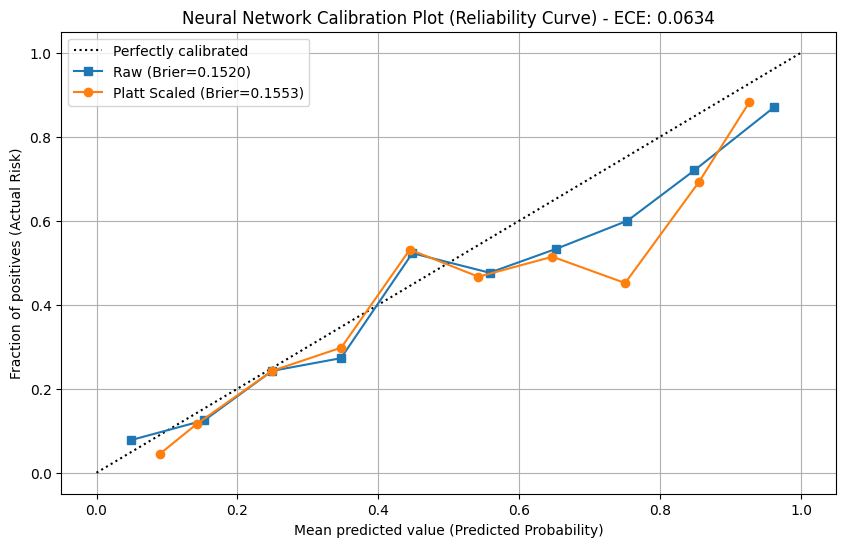

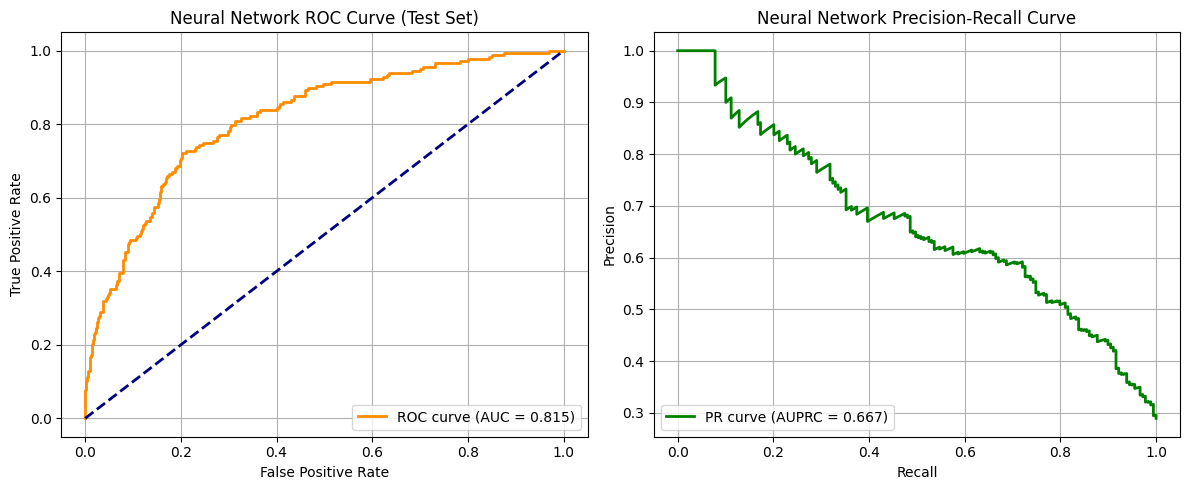

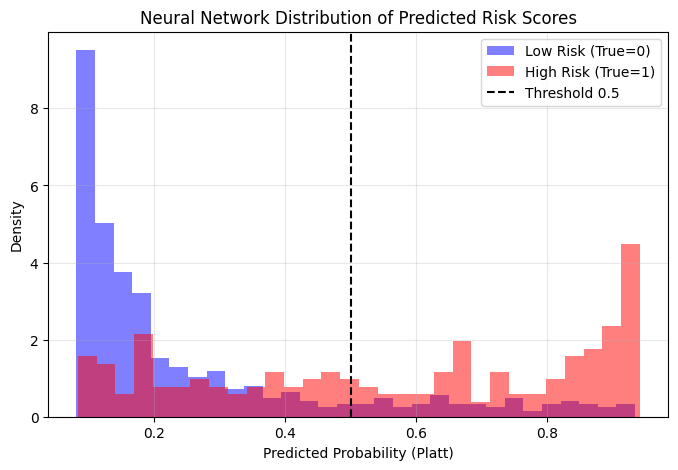

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_curve, auc, precision_recall_curve, average_precision_score

file_path = "ML and FT/project/outputs/nn_model/nn_predictions_test.csv"
try:
    preds = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"找不到檔案: {file_path}，請確認路徑。")

y_true = preds['y_true']
prob_raw = preds['p_raw']
prob_platt = preds['p_platt']

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # 落入該區間的樣本
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()  # 該區間樣本佔比
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()  # 實際違約率
            avg_confidence_in_bin = y_prob[in_bin].mean()  # 平均預測機率
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
    return ece

ece_score = expected_calibration_error(y_true, prob_platt)
#print(f"ECE Score: {ece_score:.4f}")

# ==========================================
# 畫圖：校準度分析 (Reliability Curve)
# ==========================================
plt.figure(figsize=(10, 6))

# 計算 Brier Score
brier_raw = brier_score_loss(y_true, prob_raw)
brier_platt = brier_score_loss(y_true, prob_platt)

# 畫對角線 (完美校準)
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

# 畫 Raw 模型
frac_raw, mean_raw = calibration_curve(y_true, prob_raw, n_bins=10)
plt.plot(mean_raw, frac_raw, "s-", label=f"Raw (Brier={brier_raw:.4f})")

# 畫 Platt 校準後模型
frac_platt, mean_platt = calibration_curve(y_true, prob_platt, n_bins=10)
#plt.plot(mean_platt, frac_platt, "o-", label=f"Platt Scaled (Brier={brier_platt:.4f})")


plt.plot(mean_platt, frac_platt, "o-", label=f"Platt Scaled (Brier={brier_platt:.4f})")
# 修改標題，加上 ECE
plt.title(f"Neural Network Calibration Plot (Reliability Curve) - ECE: {ece_score:.4f}")

plt.ylabel("Fraction of positives (Actual Risk)")
plt.xlabel("Mean predicted value (Predicted Probability)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# ==========================================
# 畫圖：效能指標 (ROC & PR Curve)
# ==========================================
plt.figure(figsize=(12, 5))

# --- 左圖：ROC Curve ---
plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_true, prob_platt)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Neural Network ROC Curve (Test Set)')
plt.legend(loc="lower right")
plt.grid(True)

# --- 右圖：Precision-Recall Curve ---
plt.subplot(1, 2, 2)
precision, recall, _ = precision_recall_curve(y_true, prob_platt)
auprc = average_precision_score(y_true, prob_platt)
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUPRC = {auprc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Neural Network Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 畫圖：機率分佈圖 (Risk Distribution)
# ==========================================
plt.figure(figsize=(8, 5))
plt.hist(prob_platt[y_true == 0], bins=30, alpha=0.5, label='Low Risk (True=0)', density=True, color='blue')
plt.hist(prob_platt[y_true == 1], bins=30, alpha=0.5, label='High Risk (True=1)', density=True, color='red')
plt.axvline(0.5, color='k', linestyle='--', label='Threshold 0.5')
plt.xlabel('Predicted Probability (Platt)')
plt.ylabel('Density')
plt.title('Neural Network Distribution of Predicted Risk Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### GB model 

成功找到檔案
ECE Score: 0.0715


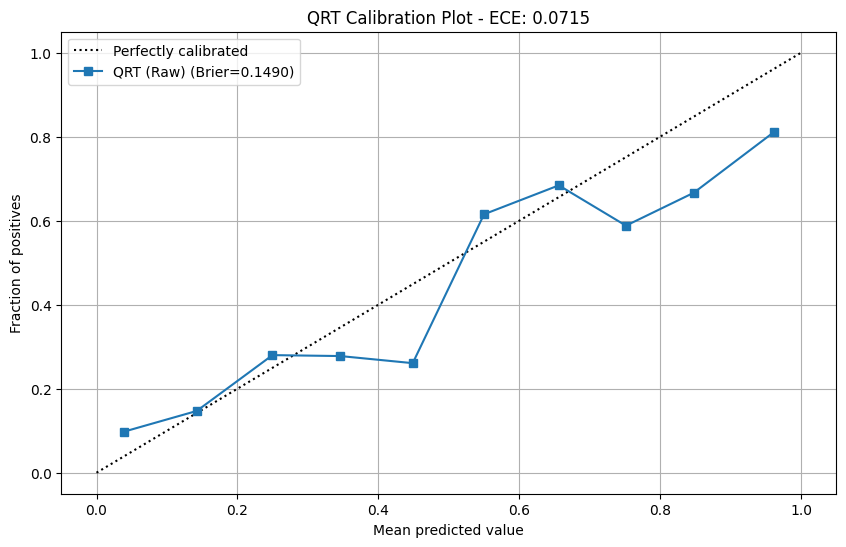

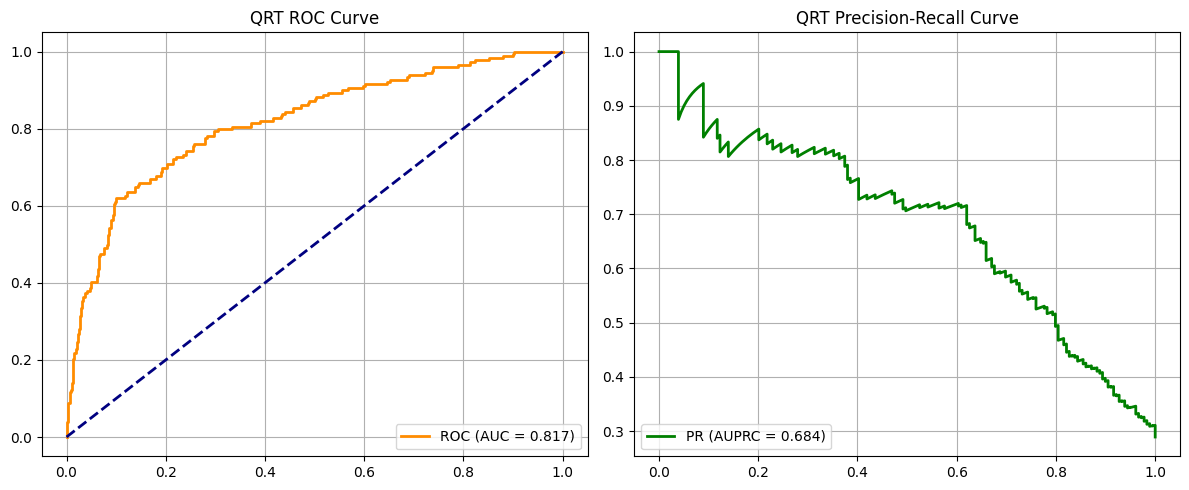

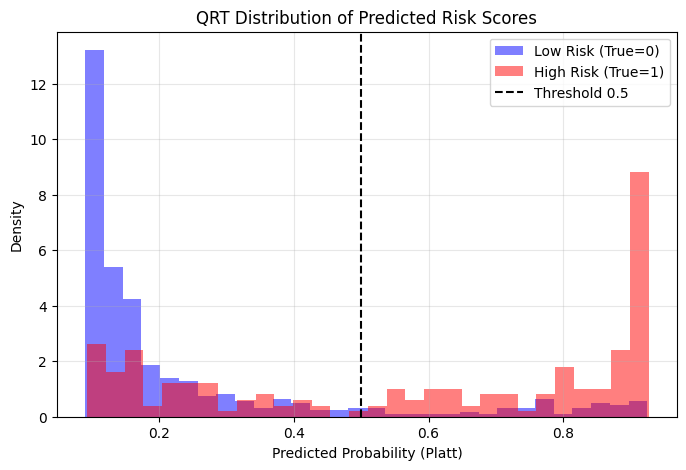

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_curve, auc, precision_recall_curve, average_precision_score


folder_name = "outputs/gb_model"  
file_name = "gb_predictions_test.csv" 

# 自動搜尋檔案
possible_paths = [
    f"{folder_name}/{file_name}",
    f"project/{folder_name}/{file_name}",
    f"ML and FT/project/{folder_name}/{file_name}",
    "gb_predictions_test.csv" 
]

file_path = None
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        print("成功找到檔案")
        break

if file_path is None:
    print("錯誤：找不到 GB 的結果檔。")
else:

    preds = pd.read_csv(file_path)
    y_true = preds['y_true']
    
   
    if 'p_platt' in preds.columns:
        print("偵測到校準機率 (p_platt)，使用校準後數據。")
        prob_main = preds['p_platt']
        model_label = "GB (Platt)"
    else:
        prob_main = preds['p_raw']
        model_label = "GB (Raw)"
    

    prob_raw = preds['p_raw']

    # 定義 ECE 計算
    def expected_calibration_error(y_true, y_prob, n_bins=10):
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        ece = 0.0
        for i in range(n_bins):
            bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i+1]
            in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
            prop = in_bin.mean()
            if prop > 0:
                acc = y_true[in_bin].mean()
                conf = y_prob[in_bin].mean()
                ece += np.abs(conf - acc) * prop
        return ece

    ece_score = expected_calibration_error(y_true, prob_main)
    print(f"ECE Score: {ece_score:.4f}")

  
    plt.figure(figsize=(10, 6))
    
    brier_main = brier_score_loss(y_true, prob_main)

    plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    
    # 畫出主要曲線
    frac_main, mean_main = calibration_curve(y_true, prob_main, n_bins=10)
    plt.plot(mean_main, frac_main, "s-", label=f"{model_label} (Brier={brier_main:.4f})")
    
    plt.title(f"GB Calibration Plot - ECE: {ece_score:.4f}")
    plt.ylabel("Fraction of positives")
    plt.xlabel("Mean predicted value")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

 
    plt.figure(figsize=(12, 5))

    # ROC
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(y_true, prob_main)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('GB ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)

    # PR Curve
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(y_true, prob_main)
    auprc = average_precision_score(y_true, prob_main)
    plt.plot(recall, precision, color='green', lw=2, label=f'PR (AUPRC = {auprc:.3f})')
    plt.title('GB Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    #plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(prob_platt[y_true == 0], bins=30, alpha=0.5, label='Low Risk (True=0)', density=True, color='blue')
    plt.hist(prob_platt[y_true == 1], bins=30, alpha=0.5, label='High Risk (True=1)', density=True, color='red')
    plt.axvline(0.5, color='k', linestyle='--', label='Threshold 0.5')
    plt.xlabel('Predicted Probability (Platt)')
    plt.ylabel('Density')
    plt.title('GB Distribution of Predicted Risk Scores')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### Random Forest

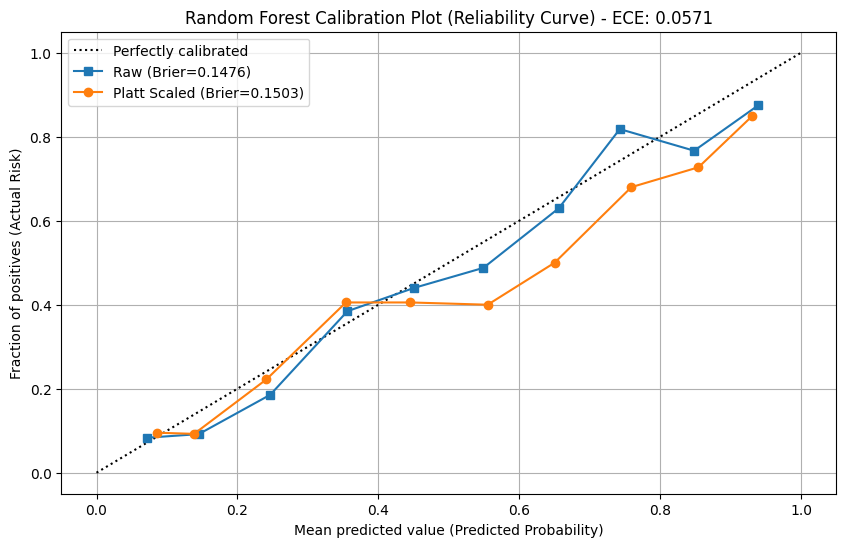

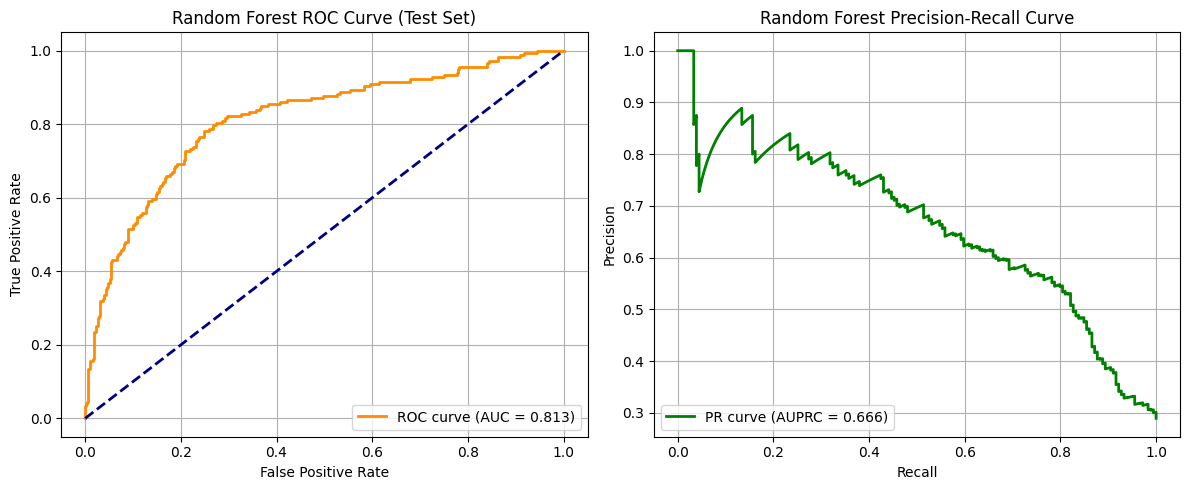

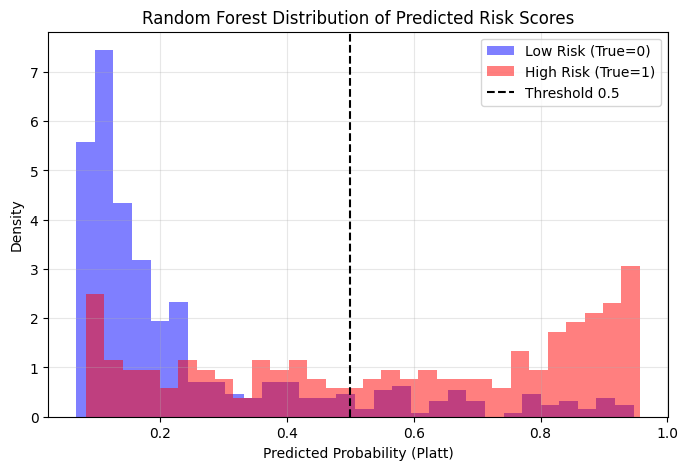

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_curve, auc, precision_recall_curve, average_precision_score

file_path = "ML and FT/project/outputs/rf_model/rf_predictions_test.csv"
try:
    preds = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"找不到檔案: {file_path}，請確認路徑。")

y_true = preds['y_true']
prob_raw = preds['p_raw']
prob_platt = preds['p_platt']

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # 落入該區間的樣本
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()  # 該區間樣本佔比
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()  # 實際違約率
            avg_confidence_in_bin = y_prob[in_bin].mean()  # 平均預測機率
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
    return ece

ece_score = expected_calibration_error(y_true, prob_platt)
#print(f"ECE Score: {ece_score:.4f}")

# ==========================================
# 畫圖：校準度分析 (Reliability Curve)
# ==========================================
plt.figure(figsize=(10, 6))

# 計算 Brier Score
brier_raw = brier_score_loss(y_true, prob_raw)
brier_platt = brier_score_loss(y_true, prob_platt)

# 畫對角線 (完美校準)
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

# 畫 Raw 模型
frac_raw, mean_raw = calibration_curve(y_true, prob_raw, n_bins=10)
plt.plot(mean_raw, frac_raw, "s-", label=f"Raw (Brier={brier_raw:.4f})")

# 畫 Platt 校準後模型
frac_platt, mean_platt = calibration_curve(y_true, prob_platt, n_bins=10)
#plt.plot(mean_platt, frac_platt, "o-", label=f"Platt Scaled (Brier={brier_platt:.4f})")


plt.plot(mean_platt, frac_platt, "o-", label=f"Platt Scaled (Brier={brier_platt:.4f})")
# 修改標題，加上 ECE
plt.title(f"Random Forest Calibration Plot (Reliability Curve) - ECE: {ece_score:.4f}")

plt.ylabel("Fraction of positives (Actual Risk)")
plt.xlabel("Mean predicted value (Predicted Probability)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# ==========================================
# 畫圖：效能指標 (ROC & PR Curve)
# ==========================================
plt.figure(figsize=(12, 5))

# --- 左圖：ROC Curve ---
plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_true, prob_platt)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve (Test Set)')
plt.legend(loc="lower right")
plt.grid(True)

# --- 右圖：Precision-Recall Curve ---
plt.subplot(1, 2, 2)
precision, recall, _ = precision_recall_curve(y_true, prob_platt)
auprc = average_precision_score(y_true, prob_platt)
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUPRC = {auprc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 畫圖：機率分佈圖 (Risk Distribution)
# ==========================================
plt.figure(figsize=(8, 5))
plt.hist(prob_platt[y_true == 0], bins=30, alpha=0.5, label='Low Risk (True=0)', density=True, color='blue')
plt.hist(prob_platt[y_true == 1], bins=30, alpha=0.5, label='High Risk (True=1)', density=True, color='red')
plt.axvline(0.5, color='k', linestyle='--', label='Threshold 0.5')
plt.xlabel('Predicted Probability (Platt)')
plt.ylabel('Density')
plt.title('Random Forest Distribution of Predicted Risk Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### SVM

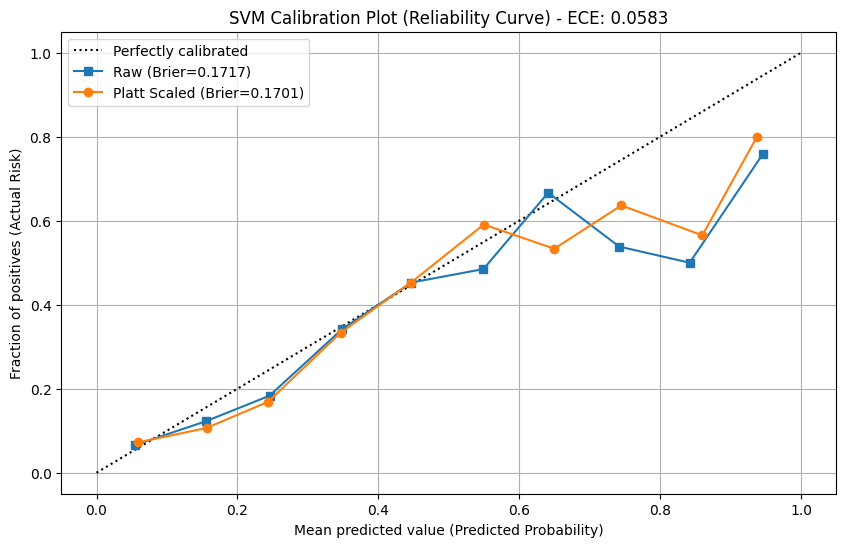

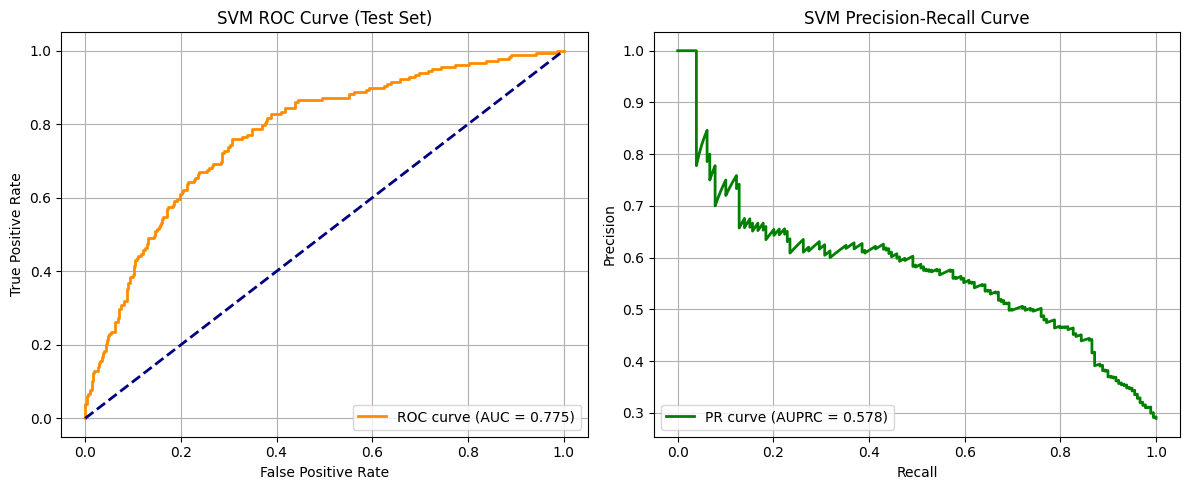

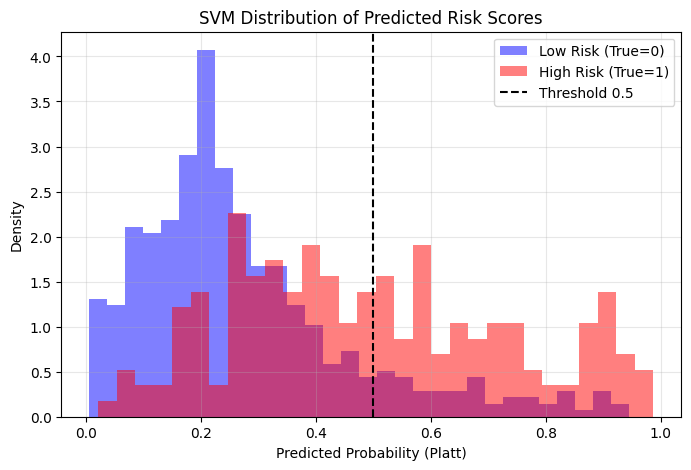

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_curve, auc, precision_recall_curve, average_precision_score

file_path = "ML and FT/project/outputs/svm_model/svm_predictions_test.csv"
try:
    preds = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"找不到檔案: {file_path}，請確認路徑。")

y_true = preds['y_true']
prob_raw = preds['p_raw']
prob_platt = preds['p_platt']

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # 落入該區間的樣本
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()  # 該區間樣本佔比
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()  # 實際違約率
            avg_confidence_in_bin = y_prob[in_bin].mean()  # 平均預測機率
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
    return ece

ece_score = expected_calibration_error(y_true, prob_platt)
#print(f"ECE Score: {ece_score:.4f}")

# ==========================================
# 畫圖：校準度分析 (Reliability Curve)
# ==========================================
plt.figure(figsize=(10, 6))

# 計算 Brier Score
brier_raw = brier_score_loss(y_true, prob_raw)
brier_platt = brier_score_loss(y_true, prob_platt)

# 畫對角線 (完美校準)
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

# 畫 Raw 模型
frac_raw, mean_raw = calibration_curve(y_true, prob_raw, n_bins=10)
plt.plot(mean_raw, frac_raw, "s-", label=f"Raw (Brier={brier_raw:.4f})")

# 畫 Platt 校準後模型
frac_platt, mean_platt = calibration_curve(y_true, prob_platt, n_bins=10)
#plt.plot(mean_platt, frac_platt, "o-", label=f"Platt Scaled (Brier={brier_platt:.4f})")


plt.plot(mean_platt, frac_platt, "o-", label=f"Platt Scaled (Brier={brier_platt:.4f})")
# 修改標題，加上 ECE
plt.title(f"SVM Calibration Plot (Reliability Curve) - ECE: {ece_score:.4f}")

plt.ylabel("Fraction of positives (Actual Risk)")
plt.xlabel("Mean predicted value (Predicted Probability)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# ==========================================
# 畫圖：效能指標 (ROC & PR Curve)
# ==========================================
plt.figure(figsize=(12, 5))

# --- 左圖：ROC Curve ---
plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_true, prob_platt)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve (Test Set)')
plt.legend(loc="lower right")
plt.grid(True)

# --- 右圖：Precision-Recall Curve ---
plt.subplot(1, 2, 2)
precision, recall, _ = precision_recall_curve(y_true, prob_platt)
auprc = average_precision_score(y_true, prob_platt)
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUPRC = {auprc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('SVM Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 畫圖：機率分佈圖 (Risk Distribution)
# ==========================================
plt.figure(figsize=(8, 5))
plt.hist(prob_platt[y_true == 0], bins=30, alpha=0.5, label='Low Risk (True=0)', density=True, color='blue')
plt.hist(prob_platt[y_true == 1], bins=30, alpha=0.5, label='High Risk (True=1)', density=True, color='red')
plt.axvline(0.5, color='k', linestyle='--', label='Threshold 0.5')
plt.xlabel('Predicted Probability (Platt)')
plt.ylabel('Density')
plt.title('SVM Distribution of Predicted Risk Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()